# Notebook 01 — Data Loading and Quality Control

**SPE Africa Geothermal Datathon 2026**

## Purpose
This notebook loads every data file provided in the challenge pack, inspects its contents, 
and documents all data quality issues found. No data is modified here — this is purely 
diagnosis. All fixes happen in Notebook 03.

## Files covered
- `data/raw/BLT-01.las` — Well log data, BLT-01
- `data/raw/EVD-01.las` — Well log data, EVD-01
- `data/raw/PKP-01.las` — Well log data, PKP-01
- `data/raw/JUT-01.las` — Well log data, JUT-01
- `data/target_lithologies.csv` — Pre-processed Rotliegend formation intervals
- `data/Lithostratigraphic_Data.xlsx` — Formation tops and bases per well
- `data/ThermoGIS_Data.xlsx` — Probabilistic reservoir properties (P90/P50/P10)
- `data/Well_Path_Data.xlsx` — Directional survey data per well

## 0. Imports and Paths

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR        = '../data'
RAW_DIR         = os.path.join(DATA_DIR, 'raw')
FIGURES_DIR     = '../outputs/figures'
PROCESSED_DIR   = '../outputs/processed_data'

WELLS = ['BLT-01', 'EVD-01', 'PKP-01', 'JUT-01']

print('Libraries loaded successfully.')
print(f'Looking for raw LAS files in: {os.path.abspath(RAW_DIR)}')

Libraries loaded successfully.
Looking for raw LAS files in: /workspaces/geothermal-datathon/data/raw


---
## 1. LAS Files — Well Log Data

LAS (Log ASCII Standard) is the industry format for borehole wireline logs.
We use the `lasio` library to parse them. Each file contains:
- A header section (well metadata, depth range, curve descriptions)
- A data section (depth vs. log measurements)

Missing values in LAS files are stored as `-999.25` by convention. 
`lasio` automatically converts these to `NaN` when loading.

In [2]:
# Load all LAS files into a dictionary
las_files = {}

for well in WELLS:
    path = os.path.join(RAW_DIR, f'{well}.las')
    las_files[well] = lasio.read(path)
    print(f'Loaded: {well}')

print('\nAll LAS files loaded.')

Loaded: BLT-01
Loaded: EVD-01
Loaded: PKP-01
Loaded: JUT-01

All LAS files loaded.


In [3]:
# Inspect each LAS file — header summary
print('=' * 65)
print(f'{"WELL":<10} {"DEPTH MIN":>12} {"DEPTH MAX":>12} {"UNIT":>6} {"N CURVES":>10}')
print('=' * 65)

for well, las in las_files.items():
    depth_min = las.index.min()
    depth_max = las.index.max()
    unit       = las.curves[0].unit.strip()
    n_curves   = len(las.curves)
    print(f'{well:<10} {depth_min:>12.1f} {depth_max:>12.1f} {unit:>6} {n_curves:>10}')

WELL          DEPTH MIN    DEPTH MAX   UNIT   N CURVES
BLT-01              0.0       2124.0      m         20
EVD-01             40.1       2196.9      M          5
PKP-01              0.2       2750.9      M          6
JUT-01              7.0      11220.0      F          5


In [4]:
# ⚠ FLAG: JUT-01 depth unit is FEET — must be converted to meters later
# All other wells are in meters (M). JUT-01 header shows unit = 'F'.
# Conversion factor: 1 foot = 0.3048 metres

print('JUT-01 depth unit:', las_files['JUT-01'].curves[0].unit)
print('Depth range in feet: {:.1f} – {:.1f} ft'.format(
    las_files['JUT-01'].index.min(),
    las_files['JUT-01'].index.max()
))
print('Depth range in metres (converted): {:.1f} – {:.1f} m'.format(
    las_files['JUT-01'].index.min() * 0.3048,
    las_files['JUT-01'].index.max() * 0.3048
))

JUT-01 depth unit: F
Depth range in feet: 7.0 – 11220.0 ft
Depth range in metres (converted): 2.1 – 3419.9 m


In [5]:
# List available log curves per well
print('Available log curves per well:\n')
for well, las in las_files.items():
    curves = [c.mnemonic for c in las.curves]
    print(f'{well}: {curves}')

Available log curves per well:

BLT-01: ['MD', 'BITSIZE', 'CALI', 'CASING_FLAG-(S)GR_NPHI_DTC', 'DRHO', 'DTC', 'DTS', 'DTST', 'GR', 'GRKT', 'GRTO', 'NPHI', 'PE', 'POTA', 'RD', 'RHOB', 'RM', 'RS', 'THOR', 'URAN']
EVD-01: ['DEPT', 'GR', 'DT', 'RHOB', 'DRHO']
PKP-01: ['DEPT', 'GR', 'DT', 'RHOB', 'DRHO', 'NPHI']
JUT-01: ['DEPT:1', 'DEPT:2', 'GR', 'DT', 'RHOB']


In [6]:
# Check missing data percentage per curve, per well
print('Missing data (%) per log curve:\n')

for well, las in las_files.items():
    df = las.df()
    missing_pct = df.isna().mean() * 100
    missing_pct = missing_pct[missing_pct > 0]  # only show curves with gaps
    
    if missing_pct.empty:
        print(f'{well}: No missing values detected.')
    else:
        print(f'{well}:')
        for curve, pct in missing_pct.items():
            print(f'  {curve:<20}: {pct:.1f}% missing')
    print()

Missing data (%) per log curve:

BLT-01:
  BITSIZE             : 8.7% missing
  CALI                : 28.4% missing
  CASING_FLAG-(S)GR_NPHI_DTC: 73.3% missing
  DRHO                : 28.3% missing
  DTC                 : 12.8% missing
  DTS                 : 28.7% missing
  DTST                : 29.9% missing
  GR                  : 2.2% missing
  GRKT                : 2.0% missing
  GRTO                : 2.0% missing
  NPHI                : 1.7% missing
  PE                  : 28.3% missing
  POTA                : 2.0% missing
  RD                  : 9.1% missing
  RHOB                : 28.3% missing
  RM                  : 9.1% missing
  RS                  : 9.1% missing
  THOR                : 2.0% missing
  URAN                : 2.0% missing

EVD-01:
  GR                  : 0.8% missing
  DT                  : 1.6% missing
  RHOB                : 85.1% missing
  DRHO                : 85.3% missing

PKP-01:
  GR                  : 3.2% missing
  DT                  : 22.7% missing

In [7]:
# BLT-01 has the richest log suite — print its full curve list with descriptions
print('BLT-01 full curve inventory:\n')
print(f'{"Mnemonic":<30} {"Unit":<10} {"Description"}')
print('-' * 70)
for curve in las_files['BLT-01'].curves:
    print(f'{curve.mnemonic:<30} {curve.unit:<10} {curve.descr}')

BLT-01 full curve inventory:

Mnemonic                       Unit       Description
----------------------------------------------------------------------
MD                             m          
BITSIZE                        in         
CALI                           in         
CASING_FLAG-(S)GR_NPHI_DTC                
DRHO                           g/cm3      
DTC                            us/ft      
DTS                            us/ft      
DTST                           us/ft      
GR                             gAPI       Reference GR
GRKT                           gAPI       Uranium free GR
GRTO                           gAPI       Total GR from SGR Tool
NPHI                           m3/m3      
PE                             b/e        
POTA                           %          
RD                             ohm.m      
RHOB                           g/cm3      
RM                             ohm.m      
RS                             ohm.m      
THOR                  

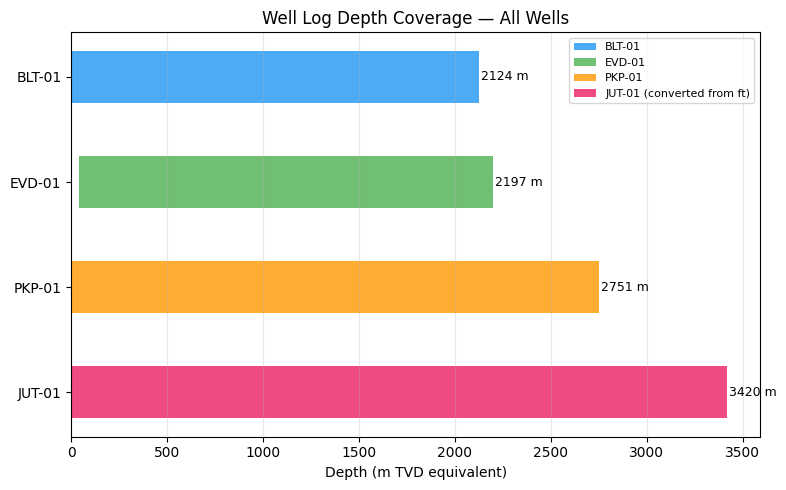

Figure saved.


In [8]:
# Quick plot: depth coverage comparison across all wells
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (well, las) in enumerate(las_files.items()):
    depth_min = las.index.min()
    depth_max = las.index.max()
    
    # Convert JUT-01 to metres for a fair comparison
    if las.curves[0].unit.strip().upper() in ['F', 'FT', 'FEET']:
        depth_min *= 0.3048
        depth_max *= 0.3048
        label = f'{well} (converted from ft)'
    else:
        label = well
    
    ax.barh(y=i, width=depth_max - depth_min, left=depth_min,
            height=0.5, color=colors[i], alpha=0.8, label=label)
    ax.text(depth_max + 10, i, f'{depth_max:.0f} m', va='center', fontsize=9)

ax.set_yticks(range(len(WELLS)))
ax.set_yticklabels(WELLS)
ax.set_xlabel('Depth (m TVD equivalent)')
ax.set_title('Well Log Depth Coverage — All Wells')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_well_depth_coverage.png'), dpi=150)
plt.show()
print('Figure saved.')

---
## 2. target_lithologies.csv

This file contains pre-processed Rotliegend formation intervals from all four wells. 
It is the core dataset for Challenge 1 — reservoir characterization.

In [9]:
litho_path = os.path.join(DATA_DIR, 'target_lithologies.csv')
df_litho   = pd.read_csv(litho_path)

print(f'Shape: {df_litho.shape[0]} rows × {df_litho.shape[1]} columns')
print(f'Wells present: {df_litho["well_id"].unique()}')
print()
print('Column names:')
print(df_litho.columns.tolist())

Shape: 3455 rows × 13 columns
Wells present: <StringArray>
['JUT-01', 'EVD-01', 'PKP-01', 'BLT-01']
Length: 4, dtype: str

Column names:
['well_id', 'easting', 'northing', 'depth_tvd_m', 'porosity_pct', 'gamma_ray_api', 'bulk_density_gcc', 'formation_top_tvd', 'formation_base_tvd', 'formation_thickness_m', 'distance_to_usp_km', 'flag', 'flag_reason']


In [10]:
df_litho.head(10)

,well_id,easting,northing,depth_tvd_m,porosity_pct,gamma_ray_api,bulk_density_gcc,formation_top_tvd,formation_base_tvd,formation_thickness_m,distance_to_usp_km,flag,flag_reason
0,JUT-01,134098.0,451726.0,NaN,NaN,43.6703,NaN,1659.5,1787.0,127.5,7.748434,check,AH depth — deviated well needs TVD conversion ...
1,JUT-01,134098.0,451726.0,NaN,NaN,42.8041,NaN,1659.5,1787.0,127.5,7.748434,check,AH depth — deviated well needs TVD conversion ...
2,JUT-01,134098.0,451726.0,NaN,NaN,42.7589,NaN,1659.5,1787.0,127.5,7.748434,check,AH depth — deviated well needs TVD conversion ...
3,JUT-01,134098.0,451726.0,NaN,NaN,43.2326,NaN,1659.5,1787.0,127.5,7.748434,check,AH depth — deviated well needs TVD conversion ...
4,JUT-01,134098.0,451726.0,NaN,NaN,44.7248,NaN,1659.5,1787.0,127.5,7.748434,check,AH depth — deviated well needs TVD conversion ...
5,JUT-01,134098.0,451726.0,NaN,NaN,46.8832,NaN,1659.5,1787.0,127.5,7.748434,check,AH depth — deviated well needs TVD conversion ...
6,JUT-01,134098.0,451726.0,NaN,NaN,49.0400,NaN,1659.5,1787.0,127.5,7.748434,check,AH depth — deviated well needs TVD conversion ...
7,JUT-01,134098.0,451726.0,NaN,NaN,49.9183,NaN,1659.5,1787.0,127.5,7.748434,check,AH depth — deviated well needs TVD conversion ...
8,JUT-01,134098.0,451726.0,NaN,NaN,47.5234,NaN,1659.5,1787.0,127.5,7.748434,check,AH depth — deviated well needs TVD conversion ...
9,JUT-01,134098.0,451726.0,NaN,NaN,45.3009,NaN,1659.5,1787.0,127.5,7.748434,check,AH depth — deviated well needs TVD conversion ...


In [11]:
# Missing value audit
missing = df_litho.isnull().sum()
missing_pct = (df_litho.isnull().mean() * 100).round(1)

audit = pd.DataFrame({
    'missing_count': missing,
    'missing_pct':   missing_pct,
    'dtype':         df_litho.dtypes
})

print('Missing value audit — target_lithologies.csv:')
print(audit.to_string())

Missing value audit — target_lithologies.csv:
                       missing_count  missing_pct    dtype
well_id                            0          0.0      str
easting                            0          0.0  float64
northing                           0          0.0  float64
depth_tvd_m                     3455        100.0  float64
porosity_pct                    1036         30.0  float64
gamma_ray_api                      0          0.0  float64
bulk_density_gcc                 256          7.4  float64
formation_top_tvd                  0          0.0  float64
formation_base_tvd                 0          0.0  float64
formation_thickness_m              0          0.0  float64
distance_to_usp_km                 0          0.0  float64
flag                               0          0.0      str
flag_reason                        0          0.0      str


In [12]:
# ⚠ FLAG: depth_tvd_m is 100% missing for all wells
# Reason: JUT-01 is a deviated well — measured depth along the borehole
# does not equal true vertical depth. The flag_reason column explains this.
# Fix: use Well Path Data directional survey in Notebook 03.

print('Unique flag reasons:')
print(df_litho['flag_reason'].unique())
print()
print('Row counts per well:')
print(df_litho['well_id'].value_counts())

Unique flag reasons:
<StringArray>
['AH depth — deviated well needs TVD conversion before use']
Length: 1, dtype: str

Row counts per well:
well_id
BLT-01    1689
EVD-01     780
PKP-01     730
JUT-01     256
Name: count, dtype: int64


In [13]:
# ⚠ FLAG: porosity_pct has 30% missing values
# Breakdown by well
print('Missing porosity_pct by well:')
missing_por = df_litho.groupby('well_id')['porosity_pct'].apply(
    lambda x: pd.Series({
        'total_rows':     len(x),
        'missing_count':  x.isna().sum(),
        'missing_pct':    round(x.isna().mean() * 100, 1)
    })
).unstack()
print(missing_por)

Missing porosity_pct by well:
         total_rows  missing_count  missing_pct
well_id                                        
BLT-01       1689.0            0.0          0.0
EVD-01        780.0          780.0        100.0
JUT-01        256.0          256.0        100.0
PKP-01        730.0            0.0          0.0


In [14]:
# Statistical summary of numeric columns
print('Descriptive statistics — numeric columns:')
df_litho.describe().round(3)

Descriptive statistics — numeric columns:


,easting,northing,depth_tvd_m,porosity_pct,gamma_ray_api,bulk_density_gcc,formation_top_tvd,formation_base_tvd,formation_thickness_m,distance_to_usp_km
count,3455.000,3455.000,0.0,2419.000,3455.000,3199.000,3455.000,3455.000,3455.000,3455.000
mean,135113.889,452221.824,NaN,14.163,47.842,2.473,2001.845,2107.241,105.396,9.601
std,8923.132,6198.355,NaN,4.315,14.239,0.090,284.682,272.484,26.326,8.346
min,118503.090,441189.000,NaN,2.922,17.417,2.281,1659.500,1787.000,73.000,2.033
25%,134098.000,451726.000,NaN,10.111,43.758,2.402,1788.000,1866.000,78.000,2.033
50%,136997.000,453402.510,NaN,15.038,48.623,2.468,1924.000,2052.700,127.500,7.748
75%,141577.550,456881.760,NaN,17.487,54.903,2.538,1924.000,2052.700,128.700,14.323
max,141577.550,456881.760,NaN,25.164,183.834,2.856,2530.500,2603.500,128.700,22.717


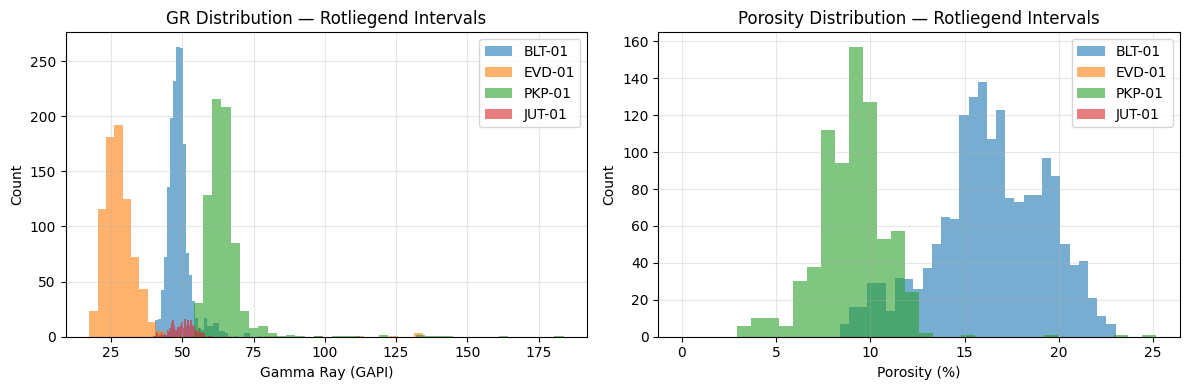

Figure saved.


In [15]:
# Plot: GR and porosity distributions per well
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for well in WELLS:
    subset = df_litho[df_litho['well_id'] == well]
    axes[0].hist(subset['gamma_ray_api'].dropna(), bins=40, alpha=0.6, label=well)
    axes[1].hist(subset['porosity_pct'].dropna(), bins=30, alpha=0.6, label=well)

axes[0].set_xlabel('Gamma Ray (GAPI)')
axes[0].set_ylabel('Count')
axes[0].set_title('GR Distribution — Rotliegend Intervals')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Porosity (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('Porosity Distribution — Rotliegend Intervals')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_litho_distributions.png'), dpi=150)
plt.show()
print('Figure saved.')

---
## 3. Lithostratigraphic Data.xlsx

Contains the full stratigraphic column for each well — formation names with top and 
bottom depths. Tells us exactly where the Rotliegend sandstone target sits in each well.

In [16]:
strat_path = os.path.join(DATA_DIR, 'Lithostratigraphic_Data.xlsx')
strat_data = {}

xl = pd.ExcelFile(strat_path)
print('Sheets found:', xl.sheet_names)

for sheet in xl.sheet_names:
    strat_data[sheet] = xl.parse(sheet)
    print(f'\n--- {sheet} ---')
    print(strat_data[sheet].to_string(index=False))

Sheets found: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']

--- BLT-01 ---
                 Stratigrafical unit  Unnamed: 1  Top (m)  Bottom (m) Anomaly code
               Upper North Sea Group         NaN     6.23        7.23          NaN
                    Boxtel Formation         NaN     7.23       14.23          NaN
                   Drenthe Formation         NaN    14.23       24.23          NaN
                  Sterksel Formation         NaN    24.23       40.23          NaN
                     Peize Formation         NaN    40.23      105.23          NaN
                 Maassluis Formation         NaN   105.23      171.23          NaN
                Oosterhout Formation         NaN   171.23      297.50          NaN
                     Breda Formation         NaN   297.50      418.00          NaN
                     Wintelre Member         NaN   418.00      462.50           UU
                         Boom Member         NaN   462.50      530.00          NaN
                

In [17]:
# Find Rotliegend-related formations in each well
rotliegend_keywords = ['Slochteren', 'Hellevoetsluis', 'Maurits', 'Rotliegend']

print('Rotliegend / target formation intervals:\n')
for well, df in strat_data.items():
    col = df.columns[0]  # formation name column
    mask = df[col].str.contains('|'.join(rotliegend_keywords), case=False, na=False)
    matches = df[mask]
    if not matches.empty:
        print(f'{well}:')
        print(matches.to_string(index=False))
        print()

Rotliegend / target formation intervals:

BLT-01:
     Stratigrafical unit  Unnamed: 1  Top (m)  Bottom (m) Anomaly code
    Slochteren Formation         NaN   1924.0      2052.7          NaN
Hellevoetsluis Formation         NaN   2052.7      2094.0          NaN
       Maurits Formation         NaN   2094.0      2123.0          NaN

EVD-01:
     Stratigrafical unit  Unnamed: 1  Top (m)  Bottom (m) Anomaly code
    Slochteren Formation         NaN   1788.0      1866.0          NaN
Hellevoetsluis Formation         NaN   1866.0      2095.0          NaN
       Maurits Formation         NaN   2095.0      2197.5           TD

JUT-01:
     Stratigrafical unit  Unnamed: 1  Top (m)  Bottom (m) Anomaly code
    Slochteren Formation         NaN   1659.5      1787.0          NaN
Hellevoetsluis Formation         NaN   1787.0      2211.0          NaN
       Maurits Formation         NaN   2211.0      2346.0          NaN
    Slochteren Formation         NaN   3240.0      3378.0          NaN
Hellevoet

---
## 4. ThermoGIS Data.xlsx

Probabilistic reservoir properties from the Dutch ThermoGIS public database.
P90 = pessimistic, P50 = most likely, P10 = optimistic.
This is the primary input for the geothermal power calculations in Notebook 05.

In [18]:
thermo_path = os.path.join(DATA_DIR, 'ThermoGIS_Data.xlsx')
thermo_data = {}

xl_thermo = pd.ExcelFile(thermo_path)
print('Sheets found:', xl_thermo.sheet_names)

for sheet in xl_thermo.sheet_names:
    thermo_data[sheet] = xl_thermo.parse(sheet, header=None)

# Display BLT-01 as a sample
print('\nSample — BLT-01:')
thermo_data['BLT-01']

Sheets found: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']

Sample — BLT-01:


,0,1,2,3,4
0,Well Name,PKP-01,NaN,NaN,NaN
1,x,141577.55,NaN,NaN,NaN
2,Y,456881.76,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Property,Unit,P90,P50,P10
5,Permeability,mD,13,82,521
6,Top Depth,m,1837,1837,1837
7,Thickness,m,67,130,194
8,Porosity,%,17,17,17
9,Net-to-gross,-,0.98,0.98,0.98


In [19]:
# Parse ThermoGIS into a clean summary table
# The xlsx has a non-standard layout — we read the property rows manually

records = []

for well, df in thermo_data.items():
    # Row 0 = well name header, Row 1 = coordinates, Row 2 = column headers,
    # Rows 3+ = property rows (Property, Unit, P90, P50, P10)
    try:
        data_rows = df.iloc[3:].copy()
        data_rows.columns = ['Property', 'Unit', 'P90', 'P50', 'P10']
        data_rows = data_rows.dropna(subset=['Property'])
        data_rows['Well'] = well
        records.append(data_rows)
    except Exception as e:
        print(f'Could not parse {well}: {e}')

df_thermo = pd.concat(records, ignore_index=True)
df_thermo = df_thermo[['Well', 'Property', 'Unit', 'P90', 'P50', 'P10']]

print('ThermoGIS summary table:')
df_thermo

ThermoGIS summary table:


,Well,Property,Unit,P90,P50,P10
0,BLT-01,Property,Unit,P90,P50,P10
1,BLT-01,Permeability,mD,13,82,521
2,BLT-01,Top Depth,m,1837,1837,1837
3,BLT-01,Thickness,m,67,130,194
4,BLT-01,Porosity,%,17,17,17
5,BLT-01,Net-to-gross,-,0.98,0.98,0.98
6,BLT-01,Transmissivity,Dm,1.3,9.3,66.1
7,BLT-01,Temperature,Celcius,77,77,77
8,BLT-01,Flow Rate,m^3/h,17,105,469
9,BLT-01,Power,MW,0.6,5.1,23.7


In [20]:
# Focus on Power (MW) — the key metric for Challenge 1
power_rows = df_thermo[df_thermo['Property'].str.strip() == 'Power'].copy()
power_rows[['P90', 'P50', 'P10']] = power_rows[['P90', 'P50', 'P10']].apply(pd.to_numeric, errors='coerce')

print('Deliverable thermal power per well (MW):\n')
print(power_rows[['Well', 'P90', 'P50', 'P10']].to_string(index=False))

print()
print(f'Combined P50 power (all wells): {power_rows["P50"].sum():.1f} MW')
print(f'District heating target:         10.0 MW')
print(f'Gap at P50:                      {10.0 - power_rows["P50"].sum():.1f} MW — must be covered by system design')

Deliverable thermal power per well (MW):

  Well  P90  P50  P10
BLT-01  0.6  5.1 23.7
EVD-01  0.0  0.0  0.0
JUT-01  1.0  2.3  4.8
PKP-01  0.0  0.0  0.0

Combined P50 power (all wells): 7.4 MW
District heating target:         10.0 MW
Gap at P50:                      2.6 MW — must be covered by system design


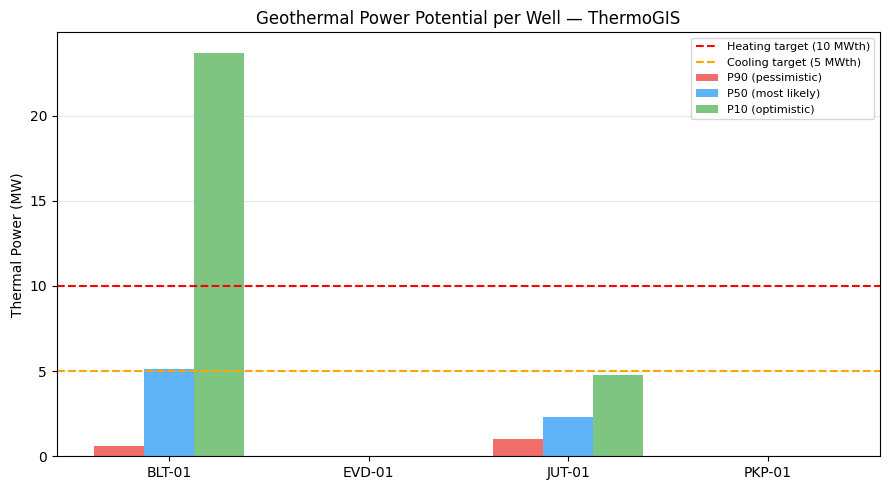

Figure saved.


In [21]:
# Bar chart: Power per well at P90 / P50 / P10
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(len(power_rows))
width = 0.25

ax.bar(x - width, power_rows['P90'].values, width, label='P90 (pessimistic)', color='#EF5350', alpha=0.85)
ax.bar(x,         power_rows['P50'].values, width, label='P50 (most likely)',  color='#42A5F5', alpha=0.85)
ax.bar(x + width, power_rows['P10'].values, width, label='P10 (optimistic)',   color='#66BB6A', alpha=0.85)

ax.axhline(y=10, color='red',    linestyle='--', linewidth=1.5, label='Heating target (10 MWth)')
ax.axhline(y=5,  color='orange', linestyle='--', linewidth=1.5, label='Cooling target (5 MWth)')

ax.set_xticks(x)
ax.set_xticklabels(power_rows['Well'].values)
ax.set_ylabel('Thermal Power (MW)')
ax.set_title('Geothermal Power Potential per Well — ThermoGIS')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_thermo_power_comparison.png'), dpi=150)
plt.show()
print('Figure saved.')

---
## 5. Well Path Data.xlsx

Directional survey data for each well: Measured Depth, Inclination, Azimuth, TVD, X-offset, Y-offset.
This is used in Notebook 03 to convert JUT-01 measured depths to true vertical depth.

In [22]:
wellpath_path = os.path.join(DATA_DIR, 'Well_Path_Data.xlsx')
wellpath_data = {}

xl_wp = pd.ExcelFile(wellpath_path)
print('Sheets found:', xl_wp.sheet_names)

for sheet in xl_wp.sheet_names:
    wellpath_data[sheet] = xl_wp.parse(sheet)

# Preview BLT-01 as sample
print('\nSample — BLT-01 (first 5 rows):')
print(wellpath_data['BLT-01'].head())

Sheets found: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']

Sample — BLT-01 (first 5 rows):
   Depth (m)  Inclination (º)  Azimuth (º)  TVD (m)  X-offset (m)  \
0       0.00             0.00          0.0     0.00          0.00   
1       6.23             0.00          0.0     6.23          0.00   
2      53.00             0.26          0.0    53.00          0.00   
3     116.00             0.25          0.0   116.00         -0.01   
4     175.10             0.61          0.0   175.10         -0.03   

   Y-offset (m)  
0          0.00  
1          0.00  
2          0.11  
3          0.39  
4          0.83  


In [23]:
# Summary: max depth and max inclination per well
print('Well path summary:\n')
print(f'{"Well":<10} {"Max MD (m)":>12} {"Max TVD (m)":>13} {"Max Incl (°)":>14}')
print('-' * 52)

for well, df in wellpath_data.items():
    cols = df.columns.tolist()
    md_col   = [c for c in cols if 'Depth' in c or 'depth' in c or 'MD' in c][0]
    tvd_col  = [c for c in cols if 'TVD' in c or 'tvd' in c][0]
    incl_col = [c for c in cols if 'Incl' in c or 'incl' in c][0]
    
    print(f'{well:<10} {df[md_col].max():>12.1f} {df[tvd_col].max():>13.1f} {df[incl_col].max():>14.2f}')

Well path summary:

Well         Max MD (m)   Max TVD (m)   Max Incl (°)
----------------------------------------------------
BLT-01           2123.0        2051.4          19.67
EVD-01           2197.5        2181.1          16.25
JUT-01           3409.0        3324.6          25.50
PKP-01           2751.0        2404.4          37.28


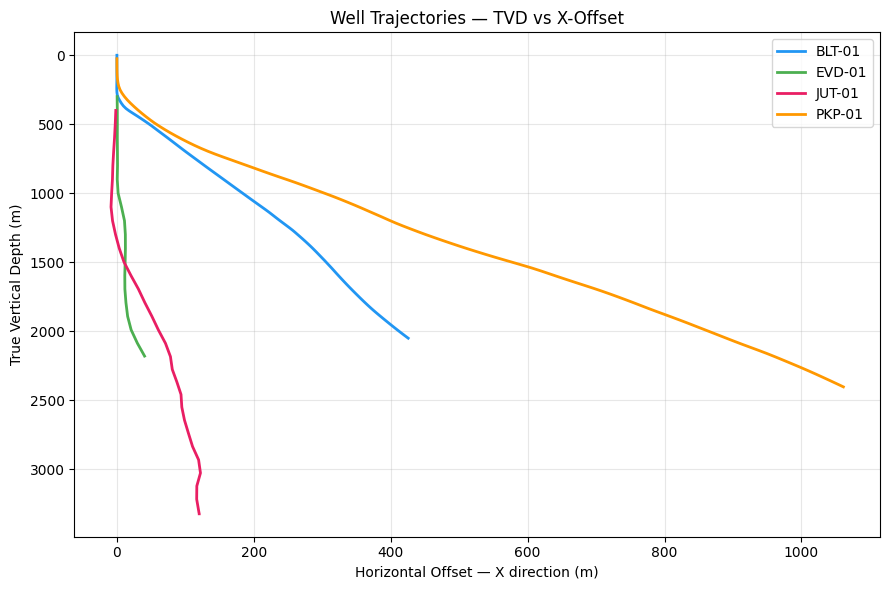

Figure saved.


In [24]:
# Plot: well trajectories (TVD vs X-offset)
fig, ax = plt.subplots(figsize=(9, 6))

colors = {'BLT-01': '#2196F3', 'EVD-01': '#4CAF50', 'PKP-01': '#FF9800', 'JUT-01': '#E91E63'}

for well, df in wellpath_data.items():
    cols    = df.columns.tolist()
    tvd_col = [c for c in cols if 'TVD' in c][0]
    x_col   = [c for c in cols if 'X' in c or 'x' in c.lower()][0]
    
    ax.plot(df[x_col], df[tvd_col], color=colors.get(well, 'gray'), label=well, linewidth=2)

ax.invert_yaxis()
ax.set_xlabel('Horizontal Offset — X direction (m)')
ax.set_ylabel('True Vertical Depth (m)')
ax.set_title('Well Trajectories — TVD vs X-Offset')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_well_trajectories.png'), dpi=150)
plt.show()
print('Figure saved.')

---
## 6. Well Locations Map

Plot the spatial distribution of all four wells using their easting/northing coordinates 
(Dutch RD New projection). This shows how spread out the wells are and which ones are 
closest to the urban supply point (USP).

In [25]:
# Extract well coordinates from target_lithologies (one row per well is enough)
well_coords = df_litho.groupby('well_id')[['easting', 'northing', 'distance_to_usp_km']].first().reset_index()

print('Well coordinates (RD New projection):')
print(well_coords.to_string(index=False))

Well coordinates (RD New projection):
well_id   easting  northing  distance_to_usp_km
 BLT-01 141577.55 456881.76            2.032828
 EVD-01 136997.00 441189.00           14.322698
 JUT-01 134098.00 451726.00            7.748434
 PKP-01 118503.09 453402.51           22.716663


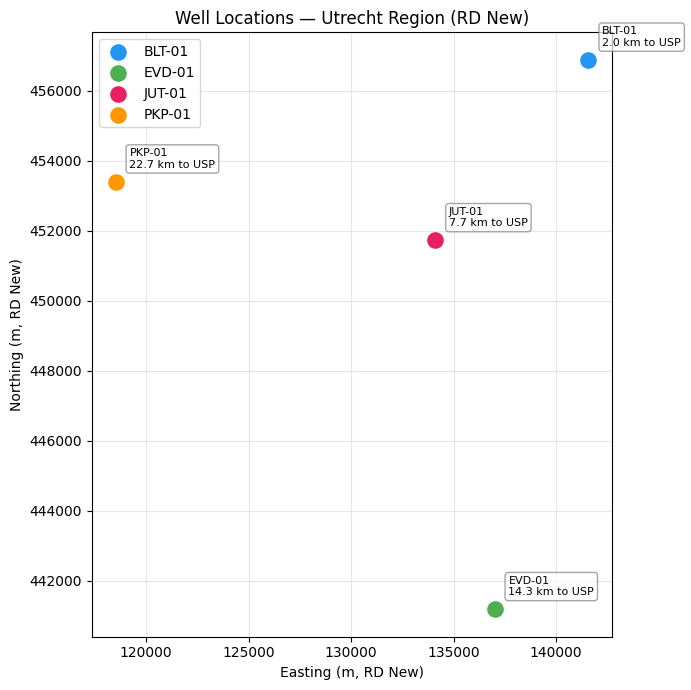

Figure saved.


In [26]:
fig, ax = plt.subplots(figsize=(7, 7))

c_map = {'BLT-01': '#2196F3', 'EVD-01': '#4CAF50', 'PKP-01': '#FF9800', 'JUT-01': '#E91E63'}

for _, row in well_coords.iterrows():
    ax.scatter(row['easting'], row['northing'],
               color=c_map.get(row['well_id'], 'gray'),
               s=120, zorder=5, label=row['well_id'])
    ax.annotate(
        f"{row['well_id']}\n{row['distance_to_usp_km']:.1f} km to USP",
        xy=(row['easting'], row['northing']),
        xytext=(10, 10), textcoords='offset points',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.7)
    )

ax.set_xlabel('Easting (m, RD New)')
ax.set_ylabel('Northing (m, RD New)')
ax.set_title('Well Locations — Utrecht Region (RD New)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_well_location_map.png'), dpi=150)
plt.show()
print('Figure saved.')

---
## 7. QC Summary — All Issues Found

This is the official record of every data problem identified. Each issue has a planned fix 
tracked to a specific notebook.

In [27]:
qc_issues = [
    {
        'ID':       'QC-01',
        'File':     'JUT-01.las',
        'Issue':    'Depth values are in FEET, not metres. All other wells are in metres.',
        'Impact':   'HIGH — all depth-dependent calculations will be wrong if not converted.',
        'Fix':      'Notebook 03 — multiply depth index by 0.3048'
    },
    {
        'ID':       'QC-02',
        'File':     'target_lithologies.csv',
        'Issue':    'depth_tvd_m column is 100% missing (3,455 / 3,455 rows).',
        'Impact':   'HIGH — true vertical depth is needed for all reservoir calculations.',
        'Fix':      'Notebook 03 — compute TVD from Well_Path_Data.xlsx directional survey'
    },
    {
        'ID':       'QC-03',
        'File':     'target_lithologies.csv',
        'Issue':    'porosity_pct is missing for 1,036 rows (30%).',
        'Impact':   'MEDIUM — affects reservoir volume and heat-in-place calculations.',
        'Fix':      'Notebook 03 — compute from density log: φ = (ρma - ρb) / (ρma - ρfl)'
    },
    {
        'ID':       'QC-04',
        'File':     'target_lithologies.csv',
        'Issue':    'bulk_density_gcc is missing for 256 rows (7.4%).',
        'Impact':   'LOW-MEDIUM — used for porosity calculation.',
        'Fix':      'Notebook 03 — impute using sonic log (DT) via empirical relationship'
    },
    {
        'ID':       'QC-05',
        'File':     'target_lithologies.csv (all rows)',
        'Issue':    'All 3,455 rows have flag = "check" due to deviated well TVD issue.',
        'Impact':   'HIGH — flags are intentional challenge prompts, not errors.',
        'Fix':      'Notebook 03 — after TVD conversion, re-evaluate and clear flags'
    },
    {
        'ID':       'QC-06',
        'File':     'ThermoGIS_Data.xlsx',
        'Issue':    'EVD-01 and PKP-01 show P50 flow rate = 0 m³/h and power = 0 MW.',
        'Impact':   'HIGH — these wells cannot produce at economic rates under P50 scenario.',
        'Fix':      'Notebook 05 — document as non-viable production wells; use for temperature data only'
    },
    {
        'ID':       'QC-07',
        'File':     'ThermoGIS_Data.xlsx',
        'Issue':    'Combined BLT-01 + JUT-01 P50 power = 7.4 MW, below the 10 MWth target.',
        'Impact':   'HIGH — resource alone cannot meet demand at most-likely scenario.',
        'Fix':      'Notebook 06 — supplement with heat pump COP uplift and hybrid system design'
    },
]

df_qc = pd.DataFrame(qc_issues)
print('QC Issues Register:\n')
for _, row in df_qc.iterrows():
    print(f"[{row['ID']}] {row['File']}")
    print(f"  Issue:  {row['Issue']}")
    print(f"  Impact: {row['Impact']}")
    print(f"  Fix:    {row['Fix']}")
    print()

# Save QC register
df_qc.to_csv(os.path.join(PROCESSED_DIR, 'qc_issues_register.csv'), index=False)
print('QC register saved to outputs/processed_data/qc_issues_register.csv')

QC Issues Register:

[QC-01] JUT-01.las
  Issue:  Depth values are in FEET, not metres. All other wells are in metres.
  Impact: HIGH — all depth-dependent calculations will be wrong if not converted.
  Fix:    Notebook 03 — multiply depth index by 0.3048

[QC-02] target_lithologies.csv
  Issue:  depth_tvd_m column is 100% missing (3,455 / 3,455 rows).
  Impact: HIGH — true vertical depth is needed for all reservoir calculations.
  Fix:    Notebook 03 — compute TVD from Well_Path_Data.xlsx directional survey

[QC-03] target_lithologies.csv
  Issue:  porosity_pct is missing for 1,036 rows (30%).
  Impact: MEDIUM — affects reservoir volume and heat-in-place calculations.
  Fix:    Notebook 03 — compute from density log: φ = (ρma - ρb) / (ρma - ρfl)

[QC-04] target_lithologies.csv
  Issue:  bulk_density_gcc is missing for 256 rows (7.4%).
  Impact: LOW-MEDIUM — used for porosity calculation.
  Fix:    Notebook 03 — impute using sonic log (DT) via empirical relationship

[QC-05] target_lit

---
## 8. Notebook Summary

| Item | Status |
|------|--------|
| 4 LAS files loaded | ✅ |
| target_lithologies.csv loaded | ✅ |
| Lithostratigraphic_Data.xlsx loaded | ✅ |
| ThermoGIS_Data.xlsx loaded | ✅ |
| Well_Path_Data.xlsx loaded | ✅ |
| QC issues documented | ✅ 7 issues found |
| Figures saved | ✅ 4 figures |

**Next:** Notebook 02 — Well Log Analysis and Formation Identification